## 24ADI204 DATA SCIENCE AND VISUALIZATION
### DATA VIZ HACK A BIT (2026-2027)

### PROBLEM STATEMENT:
#### IPL Analytics & Player Management: Optimizing Squad Building and Match Strategy

### Domain:
#### Category F: Sports & Entertainment

### Project Abstract:
This project analyzes multi-season IPL match logs, ball-by-ball records, and player statistics to optimize squad building and match strategy. Raw performance stats are cleaned, missing values are handled via median imputation, physical workload outliers are detected using the IQR method, features are standardized using StandardScaler, and Principal Component Analysis (PCA) is used to classify player playstyles and predict fatigue-driven performance drops — eliminating hype-driven auction biases.

Under the theme **"The Moneyball Blueprint: Data-Driven Performance and Workload Optimization in IPL,"** the project builds toward an interactive dashboard for cost-effective, merit-based auction strategy and injury-risk-aware squad building.

### Dataset Source:
**Dataset Name:** IPL Player & Auction Dataset (unclean, raw export)

**Source:** Kaggle

**Dataset Link:** https://www.kaggle.com/datasets/jayapriyadatascience/ipl-dataset

### SDG Aligned
**SDG 3 – Good Health and Well-being** — injury prevention and workload monitoring for elite athletes.

**SDG 8 – Decent Work and Economic Growth** — fair, merit-based, data-driven player auction valuation.


# Week 1: Team Formation & Data Setup

**Objective:** Load the raw IPL dataset and set up the environment for analysis.

# 1. Import Required Libraries and Load the Dataset

**Purpose:** Import the libraries required for data analysis and visualization, and load the raw (unclean) dataset into a Pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("IPL_data_unclean.csv")
df.head()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1.0,"Ganguly, SC",3.0,IND,KKR+,Batsman,7212.0,32,11363.0,73.70,...,106.81,42.0,363.0,10.0,36.30,7.89,27.60,2011,200000.0,400000.0
1,2.0,"Balaji, L",2.0,IND,CSK+,Bowler,51.0,27,NaN,78.94,...,72.22,1.0,1342.0,52.0,25.81,7.98,19.40,2011,100000.0,500000.0
2,3.0,"Ashwin, R",1.0,IND,CSK,Bowler,284.0,31,241.0,84.56,...,76.32,NaN,1125.0,49.0,22.96,6.23,22.14,2011,100000.0,850000.0
3,4.0,Kamran Akmal,2.0,NaN,RR,W. Keeper,2648.0,0,2924.0,84.31,...,164.10,8.0,0.0,0.0,0.00,0.00,0.00,2008,150000.0,150000.0
4,5.0,"Jaffer, W",2.0,IND,RCB,Allrounder,1944.0,2,10.0,43.47,...,107.44,3.0,0.0,0.0,0.00,0.00,0.00,2008,150000.0,NaN


# Week 2: Data Understanding

**Objective:** Inspect the raw dataset's size, structure, features, data types, missing values, duplicate records, and overall data quality before cleaning.

# 1. View Sample Records

**Purpose:** Get an initial view of the dataset and its values.

In [2]:
df.head()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1.0,"Ganguly, SC",3.0,IND,KKR+,Batsman,7212.0,32,11363.0,73.70,...,106.81,42.0,363.0,10.0,36.30,7.89,27.60,2011,200000.0,400000.0
1,2.0,"Balaji, L",2.0,IND,CSK+,Bowler,51.0,27,NaN,78.94,...,72.22,1.0,1342.0,52.0,25.81,7.98,19.40,2011,100000.0,500000.0
2,3.0,"Ashwin, R",1.0,IND,CSK,Bowler,284.0,31,241.0,84.56,...,76.32,NaN,1125.0,49.0,22.96,6.23,22.14,2011,100000.0,850000.0
3,4.0,Kamran Akmal,2.0,NaN,RR,W. Keeper,2648.0,0,2924.0,84.31,...,164.10,8.0,0.0,0.0,0.00,0.00,0.00,2008,150000.0,150000.0
4,5.0,"Jaffer, W",2.0,IND,RCB,Allrounder,1944.0,2,10.0,43.47,...,107.44,3.0,0.0,0.0,0.00,0.00,0.00,2008,150000.0,NaN


# 2. Check Dataset Shape and Column Names

**Purpose:** Understand how many records and features the raw dataset contains.

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (145, 26)

Columns: ['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE']


# 3. Check Dataset Information

**Purpose:** View data types and non-null counts for every column in one place.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         142 non-null    float64
 1   PLAYER NAME    141 non-null    str    
 2   AGE            134 non-null    float64
 3   COUNTRY        134 non-null    str    
 4   TEAM           145 non-null    str    
 5   PLAYING ROLE   134 non-null    str    
 6   T-RUNS         134 non-null    float64
 7   T-WKTS         145 non-null    int64  
 8   ODI-RUNS-S     134 non-null    float64
 9   ODI-SR-B       145 non-null    float64
 10  ODI-WKTS       145 non-null    int64  
 11  ODI-SR-BL      145 non-null    float64
 12  CAPTAINCY EXP  134 non-null    float64
 13  RUNS-S         145 non-null    int64  
 14  HS             134 non-null    float64
 15  AVE            134 non-null    float64
 16  SR-B           145 non-null    float64
 17  SIXERS         134 non-null    float64
 18  RUNS-C         134 no

# 4. Identify Feature Types

**Purpose:** Separate numerical and categorical columns so later steps (imputation, outlier detection) are applied correctly.

In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['Sl.NO.', 'AGE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE']

Categorical columns: ['PLAYER NAME', 'COUNTRY', 'TEAM', 'PLAYING ROLE']


# 5. Check Missing Values

**Purpose:** Quantify how much cleaning is required before analysis. This raw export is expected to contain real missing values (unlike a pre-cleaned dataset).

In [6]:
df.isnull().sum()

Sl.NO.            3
PLAYER NAME       4
AGE              11
COUNTRY          11
TEAM              0
PLAYING ROLE     11
T-RUNS           11
T-WKTS            0
ODI-RUNS-S       11
ODI-SR-B          0
ODI-WKTS          0
ODI-SR-BL         0
CAPTAINCY EXP    11
RUNS-S            0
HS               11
AVE              11
SR-B              0
SIXERS           11
RUNS-C           11
WKTS             11
AVE-BL            0
ECON             11
SR-BL             0
AUCTION YEAR      0
BASE PRICE       11
SOLD PRICE       11
dtype: int64

# 6. Check Duplicate Records

**Purpose:** Identify accidental repeated entries in the raw export.

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# 7. Check Unique Values (Categorical Columns)

**Purpose:** Spot inconsistent category labels — e.g. trailing symbols or short-form typos in team names — before they distort grouping/analysis.

In [8]:
for col in cat_cols:
    print(col, "->", df[col].nunique(), "unique values")
    print(df[col].unique(), "\n")

PLAYER NAME -> 126 unique values
<StringArray>
[     'Ganguly, SC',        'Balaji, L',        'Ashwin, R',
     'Kamran Akmal',        'Jaffer, W',       'Morkel, JA',
      'Hussey, MEK',        'Dhoni, MS',        'Sehwag, V',
       'Kallis, JH',
 ...
     'McCullum, BB',      'Agarkar, AB',    'Mohammad Asif',
       'Pathan, IK',        'Gayle, CH', 'Venugopal Rao, Y',
       'Styris, SB',    'Fernando, CRD',      'Abdulla, YA',
        'Steyn, DW']
Length: 127, dtype: str 

COUNTRY -> 10 unique values
<StringArray>
['IND', nan, 'SA', 'AUS', 'SL', 'ENG', 'PAK', 'NZ', 'WI', 'ZIM', 'BAN']
Length: 11, dtype: str 

TEAM -> 17 unique values
<StringArray>
[ 'KKR+',  'CSK+',   'CSK',    'RR',   'RCB',    'DD',    'MI', 'KXIP+',
   'RR+',   'KKR',  'RCB+',   'MI+',   'DD+',    'DC',   'DC+',  'KXIP',
  'KXI+']
Length: 17, dtype: str 

PLAYING ROLE -> 4 unique values
<StringArray>
['Batsman', 'Bowler', 'W. Keeper', 'Allrounder', nan]
Length: 5, dtype: str 



# 8. Statistical Summary

**Purpose:** View central tendency and spread for numerical features to spot obviously wrong values.

In [9]:
df.describe()

,Sl.NO.,AGE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
count,142.000000,134.000000,134.000000,145.000000,134.000000,145.000000,145.000000,145.000000,134.000000,145.000000,...,145.000000,134.000000,134.000000,134.000000,145.000000,134.000000,145.000000,145.000000,1.340000e+02,1.340000e+02
mean,73.281690,2.104478,2075.052239,71.310345,2653.082090,71.045724,79.634483,34.185517,0.313433,518.800000,...,110.803379,17.708955,513.425373,18.231343,23.913793,6.653731,18.037724,2009.110345,1.935821e+05,5.475224e+05
std,41.847641,0.591527,3206.871704,152.663870,3641.053452,25.883689,115.008080,25.867306,0.465629,616.270026,...,35.487239,22.886718,578.680290,22.706335,21.800014,5.520604,16.233807,1.385025,1.502424e+05,4.197451e+05
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,2.000000e+04,2.000000e+04
25%,37.250000,2.000000,16.000000,0.000000,106.750000,65.510000,1.000000,12.000000,0.000000,39.000000,...,97.330000,1.000000,0.000000,0.000000,0.000000,6.230000,0.000000,2008.000000,1.000000e+05,2.425000e+05
50%,73.500000,2.000000,503.000000,7.000000,931.500000,78.080000,28.000000,36.600000,0.000000,196.000000,...,118.100000,6.000000,300.500000,9.000000,24.890000,7.415000,20.010000,2008.000000,2.000000e+05,4.500000e+05
75%,108.750000,2.000000,2612.500000,48.000000,4035.500000,86.800000,108.000000,45.400000,1.000000,929.000000,...,129.570000,29.750000,882.500000,26.750000,35.800000,8.250000,25.860000,2011.000000,2.250000e+05,7.437500e+05
max,145.000000,3.000000,13288.000000,800.000000,18426.000000,116.660000,534.000000,150.000000,1.000000,2254.000000,...,235.490000,129.000000,1975.000000,83.000000,126.300000,38.110000,100.200000,2011.000000,1.350000e+06,1.800000e+06


# 9. Data Quality Summary

**Purpose:** Consolidate the issues found so far into one view before moving to cleaning.

In [10]:
quality_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
quality_summary[quality_summary["Missing Values"] > 0].sort_values("Missing %", ascending=False)

,Missing Values,Missing %
COUNTRY,11,7.59
AGE,11,7.59
T-RUNS,11,7.59
PLAYING ROLE,11,7.59
ODI-RUNS-S,11,7.59
CAPTAINCY EXP,11,7.59
AVE,11,7.59
HS,11,7.59
WKTS,11,7.59
ECON,11,7.59


### Week 2 Conclusion

**Insight:** The raw dataset has 145 players and 26 features covering identity, batting, bowling, and auction details. Several columns (AGE, COUNTRY, PLAYING ROLE, T-RUNS, HS, ECON, SOLD PRICE, and others) have real missing values (roughly 9–11 rows each), `PLAYER NAME` itself is missing in 4 rows, and the `TEAM` column has inconsistent labels (e.g. `KKR+` vs `KKR`, `KXI+` vs `KXIP`). This confirms the dataset genuinely needs cleaning before EDA — unlike a pre-cleaned export.

# Week 3: Data Cleaning

**Objective:** Handle missing values, fix inconsistent categorical labels, remove duplicates, and detect outliers using IQR before analysis.

# 1. Drop Non-Predictive Identifier Column

**Purpose:** `Sl.NO.` is a row index carried over from the raw export and has no analytical value.

In [11]:
df = df.drop(columns=["Sl.NO."])
df.shape

(145, 25)

# 2. Drop Rows Missing the Identity Column

**Purpose:** `PLAYER NAME` identifies each record. A missing name cannot be imputed meaningfully, so those rows are removed rather than guessed.

In [12]:
print("Rows with missing PLAYER NAME:", df['PLAYER NAME'].isnull().sum())
df = df.dropna(subset=["PLAYER NAME"])
df.shape

Rows with missing PLAYER NAME: 4


(141, 25)

# 3. Remove Duplicate Records

**Purpose:** Two players (`Chawla, PP` and `Symonds, A`) appear as exact duplicate rows in the raw export — likely a data entry error during compilation. Duplicates are dropped to avoid double-counting in analysis.

In [13]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dedup:", df.shape)

Duplicate rows before: 2
Shape after dedup: (139, 25)


# 4. Clean Categorical Values — TEAM Column

**Purpose:** `TEAM` contains trailing `+` symbols (e.g. `KKR+`, `CSK+`) and a short-form typo (`KXI+`) that make the same franchise appear as multiple categories. These are standardized to one label per team.

In [14]:
print("Before cleaning:", sorted(df['TEAM'].unique()))

df['TEAM'] = df['TEAM'].str.replace('+', '', regex=False)
df['TEAM'] = df['TEAM'].replace({'KXI': 'KXIP'})

print("\nAfter cleaning:", sorted(df['TEAM'].unique()))

Before cleaning: ['CSK', 'CSK+', 'DC', 'DC+', 'DD', 'DD+', 'KKR', 'KKR+', 'KXI+', 'KXIP', 'KXIP+', 'MI', 'MI+', 'RCB', 'RCB+', 'RR', 'RR+']

After cleaning: ['CSK', 'DC', 'DD', 'KKR', 'KXIP', 'MI', 'RCB', 'RR']


# 5. Verify Categorical Values

**Purpose:** Confirm every categorical column now holds a clean, consistent set of labels.

In [15]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
for col in cat_cols:
    print(col, "->", df[col].nunique(), "unique values:", sorted(df[col].dropna().unique()))

PLAYER NAME -> 126 unique values: ['Abdulla, YA', 'Agarkar, AB', 'Ashwin, R', 'Badrinath, S', 'Bailey, GJ', 'Balaji, L', 'Bollinger, DE', 'Botha, J', 'Boucher, MV', 'Bravo, DJ', 'Chanderpaul, S', 'Chawla, PP', 'Dhawan, S', 'Dhoni, MS', 'Dilshan, TM', 'Dinda, AB', 'Dravid, RS', 'Duminy, J-P', 'Edwards, FH', 'Fernando, CRD', 'Fleming, SP', 'Flintoff, A', 'Gambhir, G', 'Ganguly, SC', 'Gayle, CH', 'Gibbs, HH', 'Gilchrist, AC', 'Harbhajan Singh', 'Harris, RJ', 'Hayden, ML', 'Henderson, T', 'Henriques, MC', 'Hodge, BJ', 'Hopes, JR', 'Hussey, DJ', 'Hussey, MEK', 'Jadeja, RA', 'Jaffer, W', 'Jayasuriya, ST', 'Jayawardena, DPMD', 'Kaif, M', 'Kallis, JH', 'Kamran Akmal', 'Kamran Khan', 'Karthik, KD', 'Kartik, M', 'Katich, SM', 'Kohli, V', 'Kumar, P', 'Kumble, A', 'Langeveldt, CK', 'Laxman, VVS', 'Lee, B', 'Maharoof, MF', 'Malinga, SL', 'Mascarenhas, AD', 'Mathews, AD', 'McCullum, BB', 'McDonald, AB', 'McGrath, GD', 'Misbah-ul-Haq', 'Mishra, A', 'Mithun, A', 'Mohammad Asif', 'Morkel, JA', 'Morkel,

# 6. Re-check Missing Values

**Purpose:** Re-run the missing-value check after structural cleaning (identifier drop, dedup) but before imputation, to confirm what still needs to be filled.

In [16]:
df.isnull().sum()

PLAYER NAME       0
AGE              11
COUNTRY          11
TEAM              0
PLAYING ROLE     11
T-RUNS           11
T-WKTS            0
ODI-RUNS-S       10
ODI-SR-B          0
ODI-WKTS          0
ODI-SR-BL         0
CAPTAINCY EXP    10
RUNS-S            0
HS               11
AVE              10
SR-B              0
SIXERS            9
RUNS-C           10
WKTS             10
AVE-BL            0
ECON             11
SR-BL             0
AUCTION YEAR      0
BASE PRICE       11
SOLD PRICE       10
dtype: int64

# 7. Identify Feature Types (Updated)

**Purpose:** Refresh the numerical/categorical column lists after dropping `Sl.NO.` so imputation loops use the correct sets.

In [17]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['AGE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE']

Categorical columns: ['PLAYER NAME', 'COUNTRY', 'TEAM', 'PLAYING ROLE']


# 8. Handle Numerical Missing Values

**Purpose:** Fill missing numerical stats with the column median. Median is used instead of mean because performance stats (runs, wickets, prices) are skewed by a few star/high-value players, and the median is robust to that skew.

In [18]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df[num_cols].isnull().sum()

AGE              0
T-RUNS           0
T-WKTS           0
ODI-RUNS-S       0
ODI-SR-B         0
ODI-WKTS         0
ODI-SR-BL        0
CAPTAINCY EXP    0
RUNS-S           0
HS               0
AVE              0
SR-B             0
SIXERS           0
RUNS-C           0
WKTS             0
AVE-BL           0
ECON             0
SR-BL            0
AUCTION YEAR     0
BASE PRICE       0
SOLD PRICE       0
dtype: int64

# 9. Handle Categorical Missing Values

**Purpose:** Fill missing categorical values (COUNTRY, PLAYING ROLE) with the most frequent category (mode), since these are nominal labels without a numeric "average".

In [19]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df[cat_cols].isnull().sum()

PLAYER NAME     0
COUNTRY         0
TEAM            0
PLAYING ROLE    0
dtype: int64

# 10. Verify Missing Values

**Purpose:** Confirm the dataset has zero missing values remaining before analysis.

In [20]:
print("Total missing values:", df.isnull().sum().sum())
print("Final shape:", df.shape)

Total missing values: 0
Final shape: (139, 25)


# 11. Update Feature Lists

**Purpose:** Lock in the final numerical/categorical column lists to use consistently for the rest of the notebook.

In [21]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print("Numerical:", num_cols)
print("\nCategorical:", cat_cols)

Numerical: ['AGE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE', 'SOLD PRICE']

Categorical: ['PLAYER NAME', 'COUNTRY', 'TEAM', 'PLAYING ROLE']


# 12. Outlier Detection Using Boxplots

**Purpose:** Visually inspect the spread of each numerical feature and spot extreme values before deciding whether they are errors or genuine elite performers.

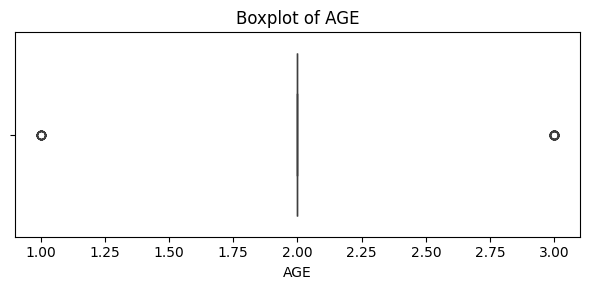

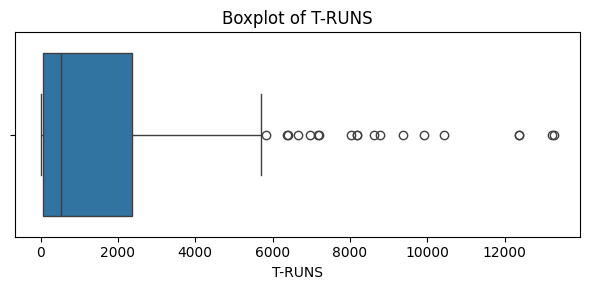

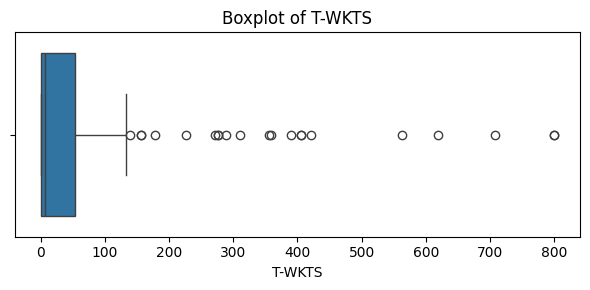

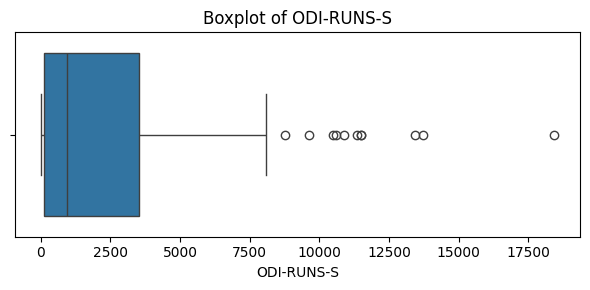

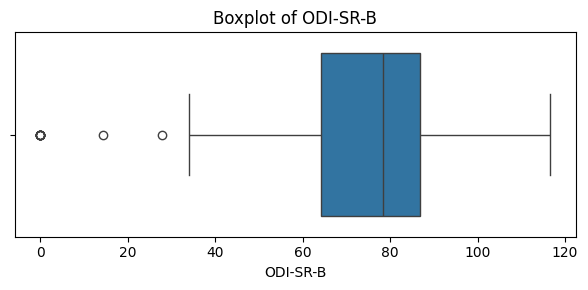

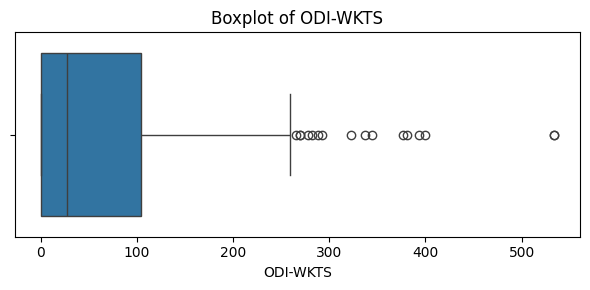

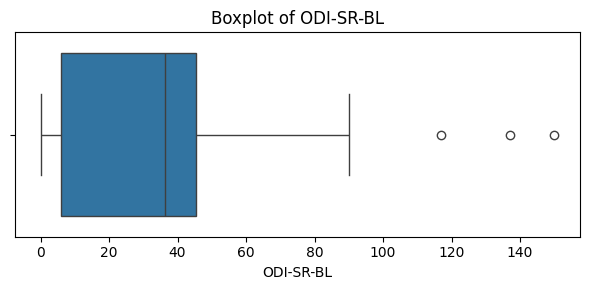

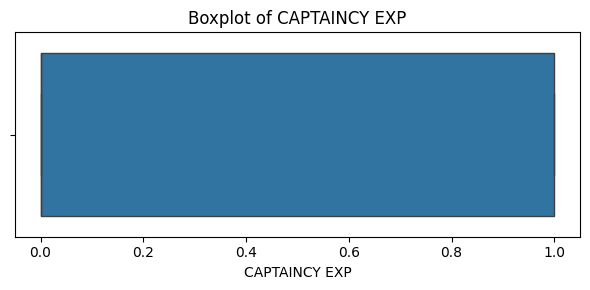

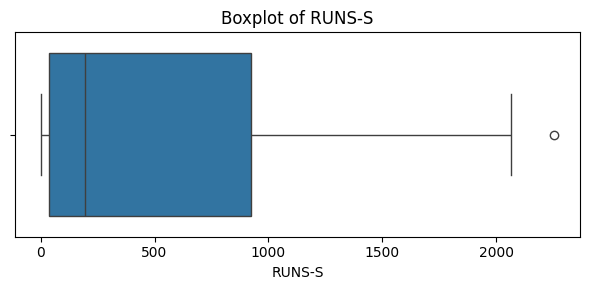

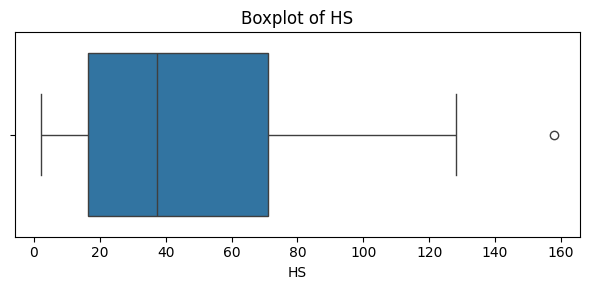

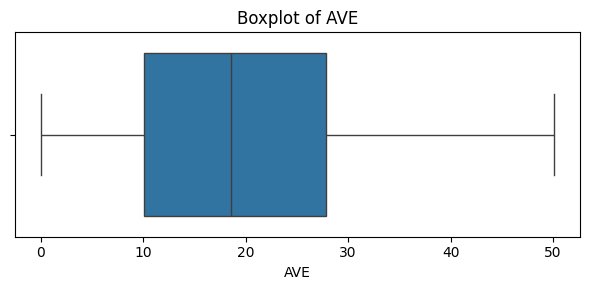

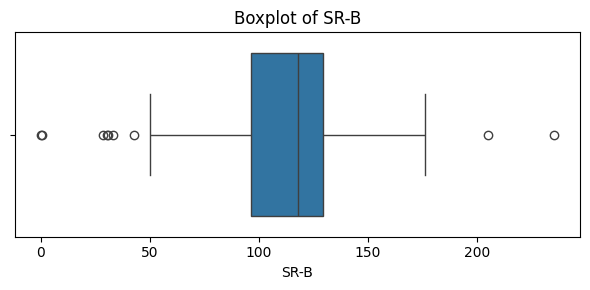

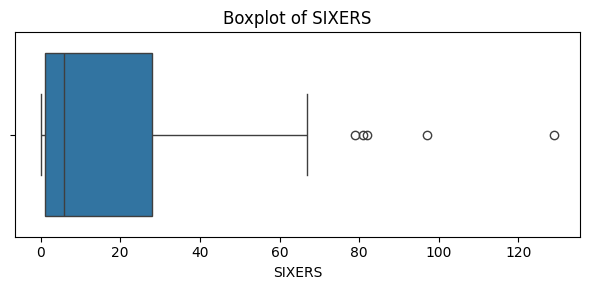

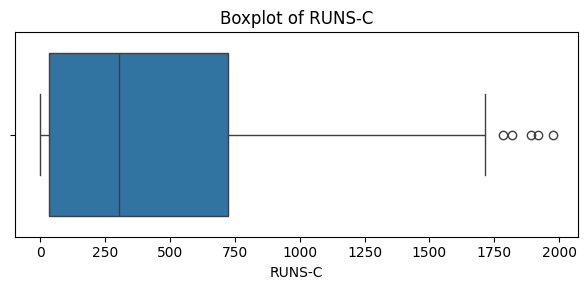

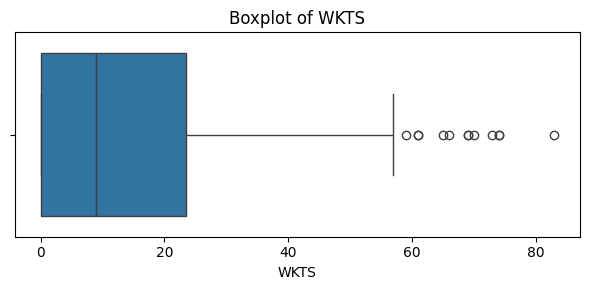

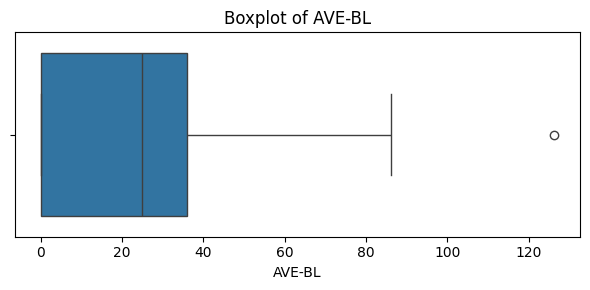

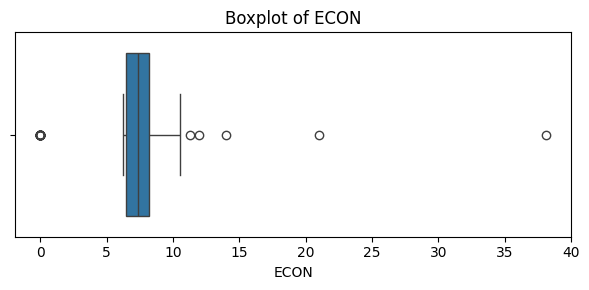

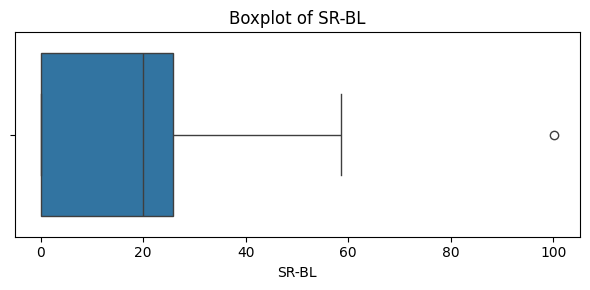

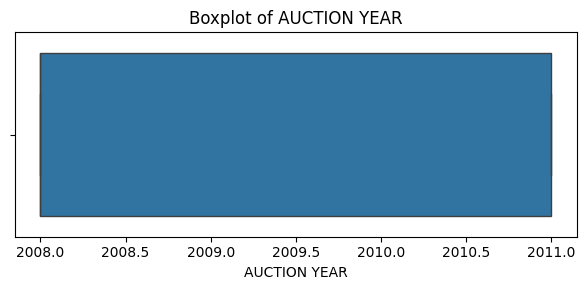

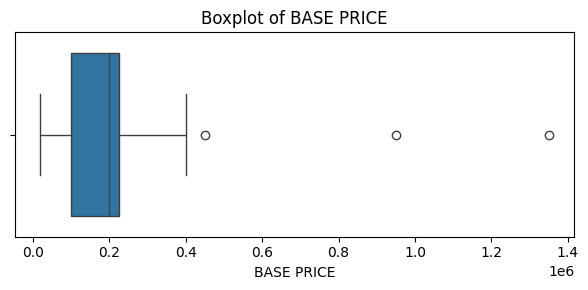

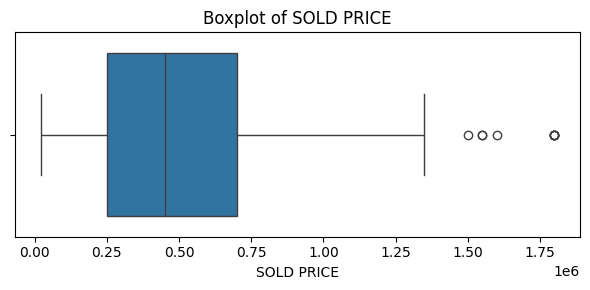

In [22]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# 13. Outlier Detection Using IQR

**Purpose:** Quantify outliers per feature using the 1.5×IQR rule, so extreme values can be interpreted (elite players / genuine workload extremes) rather than guessed from the plots alone.

In [23]:
outlier_report = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report[col] = len(outliers)
    print(col, "-> outliers:", len(outliers))

AGE -> outliers: 45
T-RUNS -> outliers: 19
T-WKTS -> outliers: 21
ODI-RUNS-S -> outliers: 11
ODI-SR-B -> outliers: 11
ODI-WKTS -> outliers: 16
ODI-SR-BL -> outliers: 3
CAPTAINCY EXP -> outliers: 0
RUNS-S -> outliers: 1
HS -> outliers: 1
AVE -> outliers: 0
SR-B -> outliers: 9
SIXERS -> outliers: 5
RUNS-C -> outliers: 5
WKTS -> outliers: 12
AVE-BL -> outliers: 1
ECON -> outliers: 36
SR-BL -> outliers: 1
AUCTION YEAR -> outliers: 0
BASE PRICE -> outliers: 3
SOLD PRICE -> outliers: 9


### Week 3 Conclusion

**Insight:** After dropping the identifier column, removing 4 rows with missing player names, and removing 2 duplicate records, the cleaned dataset has **139 players and 25 features with zero missing values**. `AGE` (45 outliers) and `ECON` (36 outliers) show the most extreme spread — `AGE` because it is actually a coded experience band (1/2/3), not literal age, so IQR is not a meaningful test for it; `ECON` because economy rate varies sharply between specialist bowlers and part-timers. Outliers in performance columns (T-RUNS, T-WKTS, SOLD PRICE) are retained, not removed — they represent genuine elite/marquee players and are central to the auction-bias investigation this project is built around.

# Week 4: Exploratory Data Analysis (EDA)

**Objective:** Explore univariate distributions, bivariate relationships, and categorical patterns to understand what drives player value and squad composition.

# 1. Univariate Analysis — Key Distributions

**Purpose:** Understand the shape (skew, spread) of the most decision-relevant numerical features.

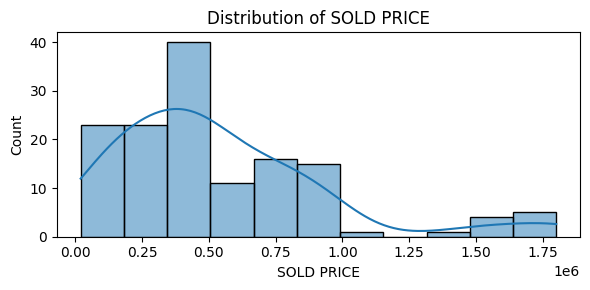

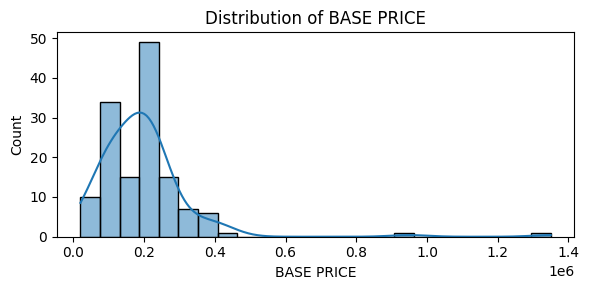

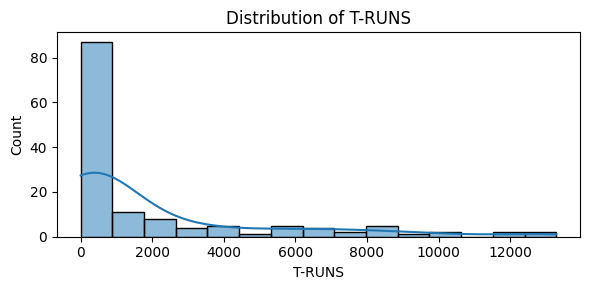

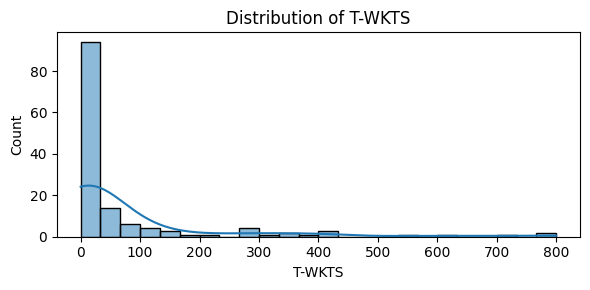

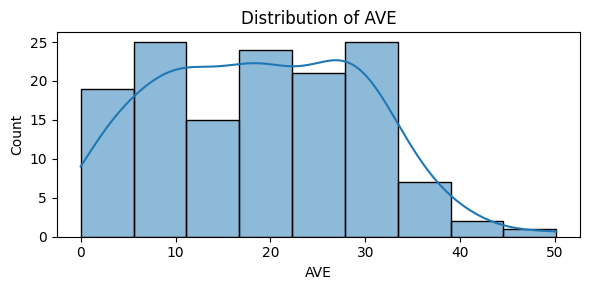

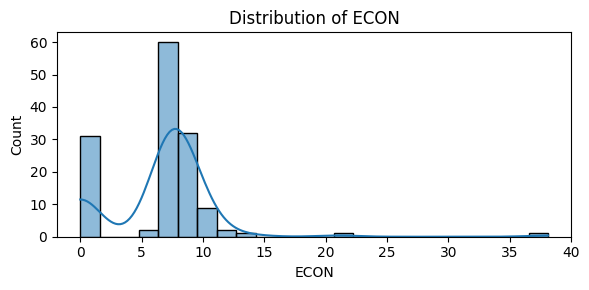

In [24]:
key_cols = ['SOLD PRICE', 'BASE PRICE', 'T-RUNS', 'T-WKTS', 'AVE', 'ECON']
for col in key_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

**Insight:** `SOLD PRICE` is right-skewed — most players sell for modest prices while a small number of star players pull the high end far up. `T-RUNS` and `T-WKTS` are similarly skewed, reflecting the natural gap between career specialists and squad fillers.

# 2. Categorical Distribution — Playing Role

**Purpose:** Understand squad composition by role, since this shapes both selection strategy and price benchmarks.

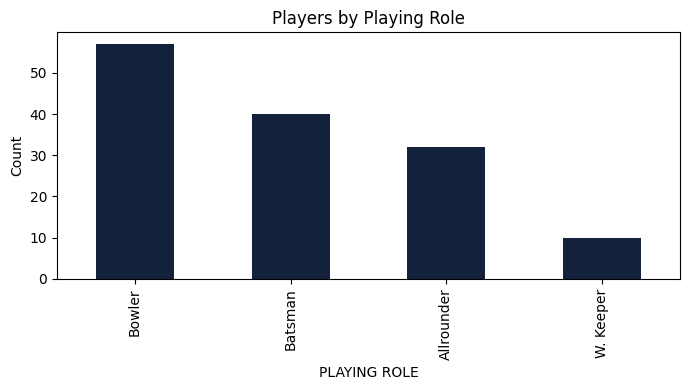

PLAYING ROLE
Bowler        57
Batsman       40
Allrounder    32
W. Keeper     10
Name: count, dtype: int64

In [25]:
plt.figure(figsize=(7, 4))
df['PLAYING ROLE'].value_counts().plot(kind='bar', color='#14213D')
plt.title("Players by Playing Role")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df['PLAYING ROLE'].value_counts()

**Insight:** Bowlers are the largest group, followed by batsmen and allrounders, with wicket-keepers the smallest specialist pool — typical of IPL squad-building priorities (batting and bowling depth over a small number of keeper slots).

# 3. Bivariate Analysis — Correlation Heatmap

**Purpose:** Identify which features move together, and specifically which performance metrics relate most strongly to `SOLD PRICE`.

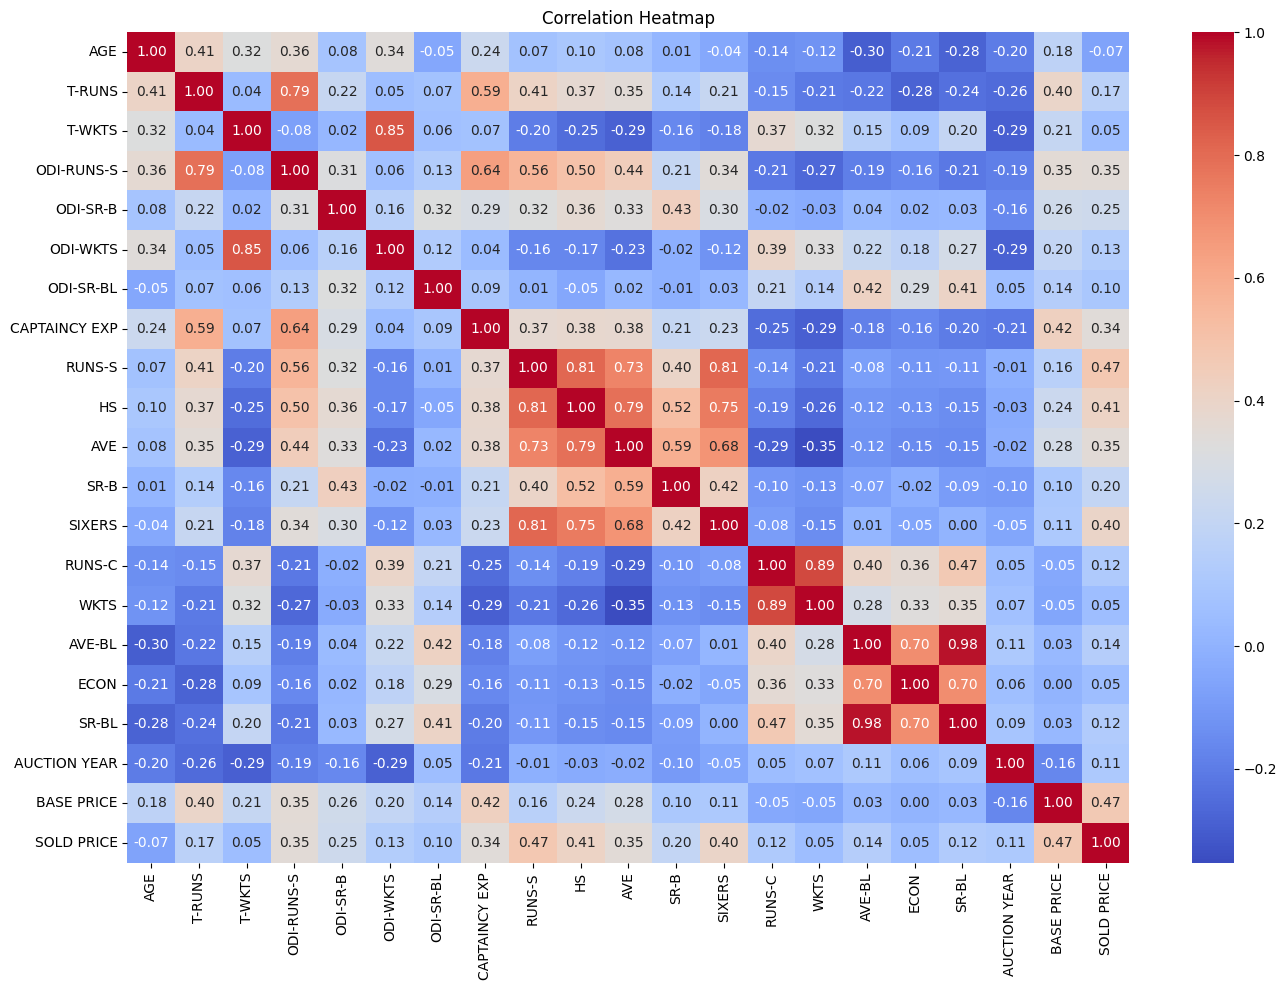

In [26]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [27]:
df[num_cols].corr()['SOLD PRICE'].sort_values(ascending=False)

SOLD PRICE       1.000000
RUNS-S           0.474906
BASE PRICE       0.466858
HS               0.411333
SIXERS           0.400237
ODI-RUNS-S       0.349757
AVE              0.346616
CAPTAINCY EXP    0.342263
ODI-SR-B         0.245715
SR-B             0.200091
T-RUNS           0.167640
AVE-BL           0.141122
ODI-WKTS         0.134194
SR-BL            0.124771
RUNS-C           0.122720
AUCTION YEAR     0.109020
ODI-SR-BL        0.097477
T-WKTS           0.053500
ECON             0.051730
WKTS             0.051100
AGE             -0.066524
Name: SOLD PRICE, dtype: float64

**Insight:** No single statistic drives `SOLD PRICE` strongly — the highest correlation (`RUNS-S`, career-stage runs) is only around 0.47-0.48, followed by `BASE PRICE`, `HS`, and `SIXERS`. This confirms the project's core premise: auction prices are influenced by more than raw performance, which is exactly the hype-driven bias this project aims to quantify and reduce using PCA-based playstyle classification.

# 4. Bivariate Analysis — Role vs. Sold Price

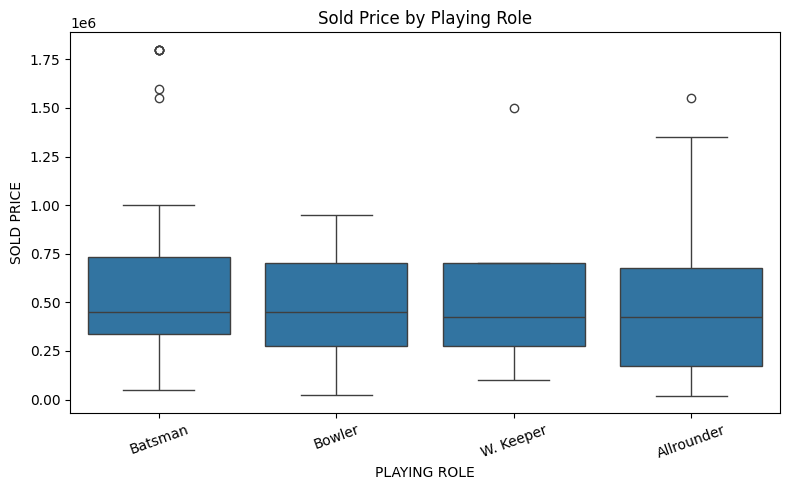

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='PLAYING ROLE', y='SOLD PRICE', data=df)
plt.title("Sold Price by Playing Role")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Insight:** Allrounders and batsmen show the highest median sold prices with wide spread, meaning teams pay a premium for dual-skill players but valuation still varies a lot within each role — supporting the project's goal of reducing role-based hype bias with objective playstyle clusters.

# 5. Performance vs. Price — Scatter

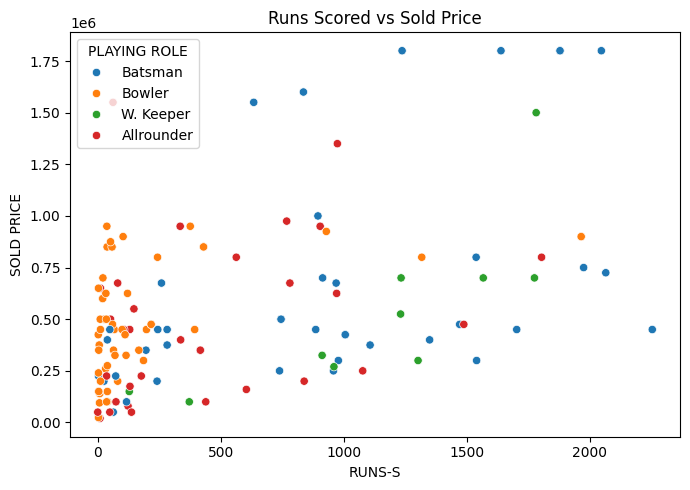

In [29]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='RUNS-S', y='SOLD PRICE', hue='PLAYING ROLE', data=df)
plt.title("Runs Scored vs Sold Price")
plt.tight_layout()
plt.show()

**Insight:** Several players with relatively low `RUNS-S` still sold for high prices, while some high-run players sold for less — reinforcing that career runs alone do not decide auction price.

### Week 4 Conclusion

The cleaned dataset (139 players, 25 features, zero missing values) was explored through univariate and bivariate analysis. `SOLD PRICE` is right-skewed and not strongly driven by any single performance metric, which supports the project's next stage: applying **StandardScaler** and **PCA** to classify player playstyles (e.g. Death-Over Specialist, Powerplay Anchor, Spin Enforcer) and build a data-driven, bias-aware auction strategy.